<a href="https://colab.research.google.com/github/RadhaKalluri/Nowak-Kalluri_TypeIISGN2026/blob/main/Copy_of_RealvsModelCClampTypeIandIIPaperFinal63026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#install necessary plugins
!pip install pyparsing==2.4.7
!pip install numpy==2.0.2
!pip install brian2==2.9.0 --no-deps
!pip install pandas==2.2.2
!pip install brian2tools
!pip install matplotlib-venn
import pandas as pd
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from brian2 import *

  Using cached brian2tools-0.3-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached setuptools_scm-10.2.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached pylems-0.6.9-py3-none-any.whl.metadata (5.0 kB)
  Using cached libneuroml-0.6.7-py3-none-any.whl.metadata (8.6 kB)
  Using cached markdown_strings-3.4.0-py2.py3-none-any.whl.metadata (7.5 kB)
  Using cached cython-3.2.8-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (4.2 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 390.8/390.8 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 76.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 161.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2

In [ ]:
#establish channel parameters
from brian2 import *

defaultclock.dt = 0.01*ms
start_scope()
Eh = -43*mV
EK = -81*mV
El = -65*mV
ENa = 81*mV

#Rothman and Manis Parameters
nf = 0.85  # proportion of n vs p kinetics
zss = 0.5 # steady state inactivation of glt
temp = 22.  # temperature in degree celcius
q10 = 3. ** ((temp - 22) / 10.)
# hcno current (octopus cell)
frac = 0.0
qt = 4.5 ** ((temp - 33.) / 10.)

# Depolarized threshold Na channel  #This implementation incorporates the tweaks from Kalluri and Hight
eqs_nad = """
ina = gnadbar*m**3*h*(ENa-v) : amp/metre**2
dm/dt=q10*(minf-m)/mtau : 1
dh/dt=q10*(hinf-h)/htau : 1
minf = 1./(1+exp(-(vu + 38.) / 4)) : 1
hinf = 1./(1+exp((vu + 65.) / 6.)) : 1
mtau = ((10. / (5*exp((vu+60.) / 18.) + 36.*exp(-(vu+60.) / 25.))) + 0.04)*ms : second
htau = ((100. / (7*exp((vu+60.) / 11.) + 10.*exp(-(vu+60.) / 25.))) + 0.6)*ms : second
gnadbar: siemens/metre**2
"""

# KHT channel (delayed-rectifier K+); note that ptau is different than in the implementation shown in Brian for Rothman and Manis ptau = ((100. / (4*exp((vu+60) / 32.) + 5*exp(-(vu+60) / 22.))) + 5)*ms : second
eqs_kht = """
ikht = gkhtbar*(nf*n**2 + (1-nf)*p)*(EK-v) : amp/metre**2
dn/dt=q10*(ninf-n)/ntau : 1
dp/dt=q10*(pinf-p)/ptau : 1
ninf =   (1 + exp(-(vu + 15) / 5.))**-0.5 : 1
pinf =  1. / (1 + exp(-(vu + 23) / 6.)) : 1
ntau =  ((100. / (11*exp((vu+60) / 24.) + 21*exp(-(vu+60) / 23.))) + 0.7)*ms : second
ptau = ((100. / (4*exp((vu+60) / 32.) + 16*exp(-(vu+60) / 22.))) + 5)*ms : second
gkhtbar: siemens/metre**2
"""
# Ih channel (subthreshold adaptive, non-inactivating)
eqs_ih = """
ih = ghbar*r*(Eh-v) : amp/metre**2
dr/dt=q10*(rinf-r)/rtau : 1
rinf = 1. / (1+exp((vu + 95.) / 7.)) : 1
rtau = ((100000. / (237.*exp((vu+60.) / 12.) + 17.*exp(-(vu+60.) / 14.))) + 25.)*ms : second
ghbar: siemens/metre**2
"""

# KLT channel (low threshold K+)#winf = (1. / (1 + exp(-(vu + 48.) / 6.)))**0.25 : 1
eqs_klt = """
iklt = gkltbar*w**4*z*(EK-v) : amp/metre**2
dw/dt=q10*(winf-w)/wtau : 1
dz/dt=q10*(zinf-z)/ztau : 1
winf = (1. / (1 + exp(-(vu + 48.) /8.)))**0.25 : 1
zinf = zss + ((1.-zss) / (1 + exp((vu + 71.) / 10.))) : 1
wtau = ((100. / (6.*exp((vu+60.) / 6.) + 16.*exp(-(vu+60.) / 45.))) + 1.5)*ms : second
ztau = ((1000. / (exp((vu+60.) / 20.) + exp(-(vu+60.) / 8.))) + 50)*ms : second
gkltbar: siemens/metre**2
"""

# Ka channel (transient K+)
eqs_ka = """
ika = gkabar*a**3*b*(EK-v): amp/metre**2
da/dt=q10*(ainf-a)/atau : 1
db/dt=q10*(binf-b)/btau : 1
ainf = (1. / (1 + exp(-(vu + 12) / 12.)))**0.33 : 1
binf = 1. / (1 + exp((vu + 76) / 20.)) : 1
atau = 1.5 *ms: second
btau = (6 + 20/(1 + exp((vu + 20)/10)))*ms : second
gkabar: siemens/metre**2
"""

# Leak
eqs_leak = """
ileak = gl*(El-v) : amp/metre**2
gl: siemens/metre**2
"""


In [ ]:
#setup equation for estimating current/voltage
C = 1*uF/cm**2
eqs_common = """
dv/dt = (1/C)*(ileak + ina + ikht + iklt + ika + ih) + I/(C*S): volt
vu = v/mV : 1
I = I_timed(t, i) : amp
S : metre**2
"""

dvdt_eq = '''
dvdt : volt/second
v_prev : volt
'''

eqs_dep = eqs_common + eqs_leak + eqs_nad + eqs_kht + eqs_klt + eqs_ka + eqs_ih

In [ ]:
#establish capacitance
Cp1 = 6.5*pF #type I/type IIM example
Cp2 = 5.5*pF #type IIS example
#Cp3 = 19.2*pF #Type IIL example
S1 = Cp1/C
S2 = Cp2/C
#S3 = Cp3/C
refractory_period = 8*ms
v_thresh = -40*mV
dvdt_thresh = 20*mV/ms

In [ ]:
# Create a neuron group with the desired number of neurons
N = 40
eqs1 = eqs_dep + dvdt_eq
neurons1 = NeuronGroup(N, eqs1, threshold='v >= v_thresh', refractory='refractory_period', method='exponential_euler')
eqs2 = eqs_dep + dvdt_eq
neurons2 = NeuronGroup(N, eqs2, threshold='v >= v_thresh', refractory='refractory_period', method='exponential_euler')

#Type I Model: type I
neurons1.v = -65*mV
neurons1.S = S1
neurons1.gl = 0.03e-3*siemens/cm**2
neurons1.gnadbar = 3.61e-3*siemens/cm**2
neurons1.ghbar = .91e-3*siemens/cm**2
neurons1.gkhtbar = 2.09e-3*siemens/cm**2
neurons1.gkltbar = 2.09e-3*siemens/cm**2
neurons1.gkabar = 0.065e-3*siemens/cm**2
mon_s1 = StateMonitor(neurons1, ['v', 'I','ih','ina','ika'], record=True)
spikes1 = SpikeMonitor(neurons1)

#Type I Model: type II
neurons2.v = -65*mV
neurons2.S = S2
neurons2.gl = 0.03e-3*siemens/cm**2
neurons2.gnadbar = 1.61e-3*siemens/cm**2
neurons2.ghbar = .91e-3*siemens/cm**2
neurons2.gkhtbar = 0.5e-3*siemens/cm**2
neurons2.gkltbar = 0.25e-3*siemens/cm**2
neurons2.gkabar = 0.69e-3*siemens/cm**2
mon_s2 = StateMonitor(neurons2, ['v', 'I','ih','ina','ika'], record=True)
spikes2 = SpikeMonitor(neurons2)




In [ ]:
#create current clamp protocol

# Define IstepIIL array with given values (in pA)
IstepIIL = np.array([
    -59.0354, -49.006, -38.8877, -28.8, -18.8166,
    -8.79029, 1.220703, 11.28384, 21.36537, 31.48678,
    41.4579, 51.37688, 61.61483, 71.62889, 81.63682,
    91.72755, 101.7938, 111.7127, 121.8004, 131.9279,
    142.077, 152.1708, 162.1357, 172.1375, 182.1761,
    192.2147, 202.2257, 212.3533, 222.4011, 232.4703,
    242.558, 252.4954, 262.5585, 272.5726, 282.5866,
    292.754, 302.854, 312.6043, 322.7318, 332.9054
]) * pA  # Multiply by pA to give the correct units (picoamperes)

# Parameters
num_pulses = 1
pulse_duration = 500*ms
gap_duration = 0*ms
pre_time = 1000*ms
post_time = 1000*ms
defaultclock.dt = 0.01*ms
dt = defaultclock.dt
pulse_steps = int(pulse_duration / dt)
gap_steps = int(gap_duration / dt)
interval_steps = pulse_steps + gap_steps
pre_steps = int(pre_time / dt)
post_steps = int(post_time / dt)

# Total simulation time in steps
total_steps = pre_steps + num_pulses * interval_steps + post_steps

# Create current array with the correct units (ampere)
I_array = np.zeros((total_steps, len(IstepIIL))) * amp  # Use ampere (A) for current

# Fill pulse times with current
for i in range(num_pulses):
    start_idx = pre_steps + i * interval_steps
    I_array[start_idx : start_idx + pulse_steps, :] = IstepIIL  # Apply IstepIIL with units directly

# Create TimedArray
I_timed = TimedArray(I_array, dt=dt)

# You can now run your simulation
run((pre_time + num_pulses * interval_steps * dt + post_time))

WARNING    'i' is an internal variable of group 'neurongroup_1', but also exists in the run namespace with the value 0. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'i' is an internal variable of group 'neurongroup', but also exists in the run namespace with the value 0. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


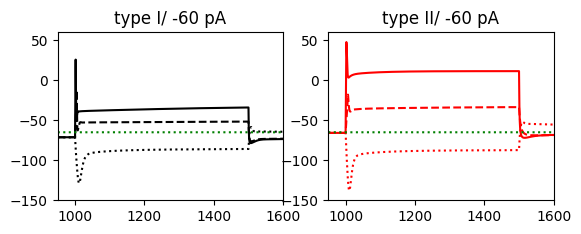

In [ ]:
## figure(1)
#plot voltage responses for type I and type II SGNs
timereplicated = tile(mon_s1.t/ms,(40,1));
voltage1 = mon_s1.v[0:40,:]/mV;
voltage2 = mon_s2.v[0:40,:]/mV;
current1 = mon_s1.I[0:40,:]/pA;
current2 = mon_s2.I[0:40,:]/pA;
dvdt1 = np.diff(voltage1, axis=1) / np.diff(timereplicated, axis=1);
dvdt2 = np.diff(voltage2, axis=1) / np.diff(timereplicated, axis=1);
import numpy as np
dvdt1_padded = np.pad(dvdt1, ((0, 0), (1, 0)), mode='constant')
dvdt2_padded = np.pad(dvdt2, ((0, 0), (1, 0)), mode='constant')

subplot(2, 2, 1)
plot(timereplicated[0,:],voltage1[0,:],'k:')
plot(timereplicated[0,:],voltage1[16,:],'k--')
plot(timereplicated[0,:],voltage1[39,:],'k')
plot(timereplicated[0,:], -65*ones_like(voltage1[0,:]),'g:')
axis([950, 1600, -150, 60])
title('type I/ -60 pA')

subplot(2, 2, 2)
plot(timereplicated[0,:],voltage2[0,:],'r:')
plot(timereplicated[0,:],voltage2[10,:],'r--')
plot(timereplicated[0,:],voltage2[39,:],'r')
plot(timereplicated[0,:], -65*ones_like(voltage2[0,:]),'g:')
axis([950, 1600, -150, 60])
title('type II/ -60 pA')

#plt.savefig("TypeIandIICClamp.pdf", format="pdf", bbox_inches="tight")
plt.show()
from google.colab import files
#files.download("TypeIandIICClamp.pdf")


Index closest to 1450 ms: 145000 -> 1450.0000000000002 ms


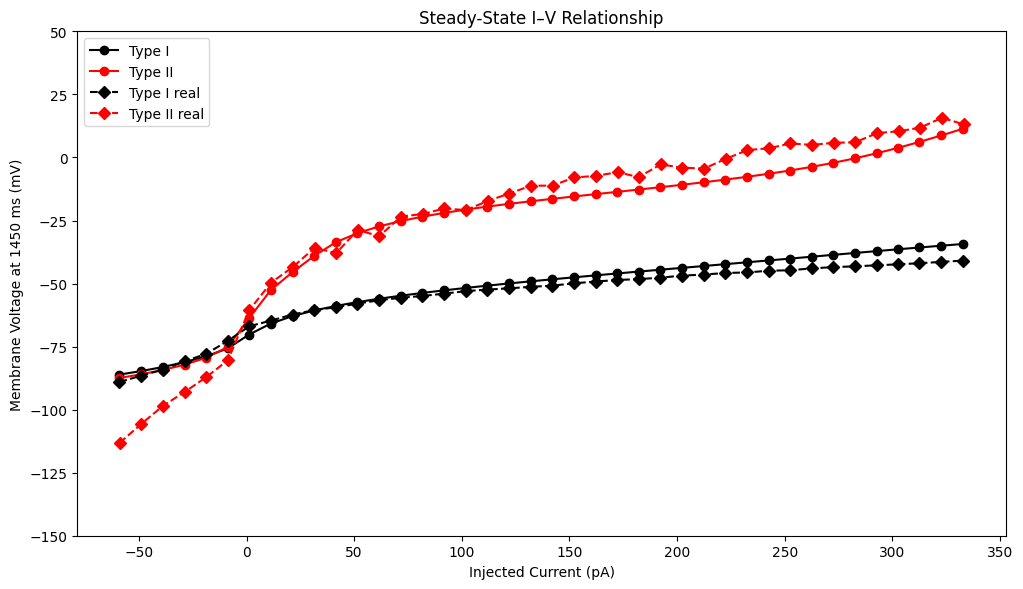

In [ ]:
#plot current voltage input output function based on steady state values
target_time = 1450 * ms
target_idx = np.argmin(np.abs(mon_s1.t - target_time))
print("Index closest to 1450 ms:", target_idx, "->", mon_s1.t[target_idx]/ms, "ms")
# Voltage at 1450 ms
v1450_s1 = mon_s1.v[:, target_idx] / mV
v1450_s2 = mon_s2.v[:, target_idx] / mV
import numpy as np

# === Type I ===
V_typeI = np.array([
-89.05888282, -86.53604519, -84.12960375, -80.82481067, -77.91245218,
-72.77461076, -66.94636662, -64.71260254, -62.28300454, -60.52832044,
-59.40346395, -57.99505469, -56.60121412, -55.62848546, -54.93271534,
-54.00583973, -53.01547528, -52.40113649, -51.91254852, -51.30173688,
-50.8310914, -49.90145541, -49.21534663, -48.595027, -48.24215791,
-47.67934628, -46.85951223, -46.44024057, -45.81363339, -45.59755667,
-44.92279613, -44.72450855, -43.98227196, -43.484176, -43.17884685,
-42.76494261, -42.36729395, -41.9415814, -41.41526818, -40.9016834
])

I_typeI = np.array([
-59.03540863, -49.00601408, -38.88767384, -28.80000452, -18.81661637,
-8.79028892, 1.220703067, 11.28383564, 21.36537077, 31.48677811,
41.45789788, 51.37687707, 61.61483395, 71.62889303, 81.63681793,
91.72755434, 101.793754, 111.7127332, 121.8004025, 131.927944,
142.0769552, 152.1707587, 162.1357443, 172.137535, 182.1761308,
192.2147267, 202.2257186, 212.3532602, 222.4010573, 232.470324,
242.5579933, 252.4953751, 262.5585077, 272.5725667, 282.5866258,
292.7540396, 302.8539773, 312.6042663, 322.7318078, 332.9053558
])

# === Type II ===
I_typeII = np.array([
-58.9587313, -48.89866582, -38.8140636, -28.66505242, -18.73993904,
-8.713611591, 1.33111842, 11.46786123, 21.52179252, 31.62786439,
41.65419184, 51.59157359, 61.71604803, 71.81291862, 81.83924607,
91.89624446, 101.9532428, 111.9581006, 121.9537572, 131.9954201,
142.1566996, 152.3333146, 162.2645622, 172.3644999, 182.2221372,
192.3343433, 202.3729391, 212.4514072, 222.621888, 232.700356,
242.745086, 252.6517968, 262.7302649, 272.7228543, 282.8258591,
292.9288639, 302.9214533, 312.9293782, 323.0385172, 333.0893814
])

V_typeII = np.array([
-113.1857126, -105.6708738, -98.48574758, -92.9533246, -87.1195597,
-80.44617799, -60.44244182, -49.60318058, -43.43065522, -35.82610397,
-37.94362522, -28.80506724, -31.18037768, -23.43213311, -22.42029902,
-20.23054772, -20.88475873, -17.25562053, -14.34970294, -11.23629648,
-11.12572776, -7.933036943, -7.308116674, -5.855694619, -7.787503364,
-2.785534178, -4.01313829, -4.443911551, -0.567872333, 2.921713123,
3.653981659, 5.537176975, 4.986633719, 5.802787259, 6.03051894,
9.66349101, 10.38502472, 11.80938287, 15.73357545, 13.14694228
])

# Current step amplitudes
Ivals = IstepIIL / pA
import matplotlib.pyplot as plt

plt.figure(figsize=(11.98, 6.55))

plt.plot(Ivals, v1450_s1, 'ko-', label='Type I')
plt.plot(Ivals, v1450_s2, 'ro-', label='Type II')
plt.plot(I_typeI, V_typeI, 'kD--', label='Type I real')
plt.plot(I_typeII, V_typeII, 'rD--', label='Type II real')

plt.xlabel('Injected Current (pA)')
plt.ylabel('Membrane Voltage at 1450 ms (mV)')
plt.title('Steady-State I–V Relationship')
plt.legend()
plt.ylim(-150, 50)

#plt.savefig("TypeIandIICClampRealvsModel.pdf", format="pdf", bbox_inches="tight") #remove # to save pdf of plot
plt.show()
#from google.colab import files
#files.download("TypeIandIICClampRealvsMode.pdf")